# Clase 23 — Datos, sesgos y cómo aprende una IA

**Diplomado IA Aplicada al Diseño · UDD · 2026** · Prof. Darío Osorio

Ejecuta las celdas en orden. Donde diga `# TU TURNO`, modifica lo indicado.

## Objetivos del notebook
1. Cargar y explorar un dataset real (reseñas en español).
2. Detectar visualmente balance de clases y valores faltantes.
3. Identificar un sesgo posible.

**Archivos necesarios**: `Clase_23_dataset_resenas_es.csv` (súbelo a Colab junto con este notebook, ver Paso 1).

## Paso 0 — Instalación


In [1]:
!pip install -q pandas matplotlib seaborn
print("Listo.")

Listo.


## Paso 1 — Subir y cargar el dataset

Este notebook usa un dataset local (`Clase_23_dataset_resenas_es.csv`), preparado por el profesor: 1000+ reseñas de productos en español, con distribución realista (desbalanceada) y algunos valores faltantes / duplicados a propósito, para que los detectes tú.

Antes de ejecutar la siguiente celda: `Archivo → Subir cuaderno` ya lo hiciste; ahora sube también el CSV con el ícono de carpeta (📁) a la izquierda → `Subir a almacenamiento de sesión` → selecciona `Clase_23_dataset_resenas_es.csv`.

In [20]:
import pandas as pd

# Dataset local (no depende de descargas externas ni de conexión inestable en vivo)
df = pd.read_csv("Clase_23_dataset_resenas_es.csv")

print(f"Cargadas {len(df)} filas")
print(f"Columnas disponibles: {df.columns.tolist()}")
df.head()

Cargadas 1012 filas
Columnas disponibles: ['id', 'text', 'stars', 'categoria']


,id,text,stars,categoria
0,1,"Esperaba algo mejor, la verdad. El escritorio ...",2,mueble
1,2,NaN,3,electronica
2,3,Muy recomendado. Se nota el cuidado en los det...,5,textil
3,4,No lo recomiendo para nada. Compré una agenda ...,1,papeleria
4,5,"Perfecto, tal cual se describe. Combina perfec...",5,papeleria


In [21]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1TURiqmrwN2jVGwfazgB5lol6-e2O_X5soc2SJichRiA/edit#gid=0


## Paso 2 — Ver primeras filas

In [22]:
df[['text', 'stars']].head(100)

,text,stars
0,"Esperaba algo mejor, la verdad. El escritorio ...",2
1,NaN,3
2,Muy recomendado. Se nota el cuidado en los det...,5
3,No lo recomiendo para nada. Compré una agenda ...,1
4,"Perfecto, tal cual se describe. Combina perfec...",5
...,...,...
95,Cargador rápido de Norden: está bien para el p...,3
96,Muy recomendado. El diseño es precioso y funci...,5
97,Superó mis expectativas. La calidad de los mat...,5
98,Cumple bien lo que promete. El acabado se ve m...,4


## Paso 3 — Balance de clases (¿está equilibrado?)

Cantidad por cada calificacion (1-5 estrellas):
stars
1    301
2    142
3     91
4    151
5    327
Name: count, dtype: int64


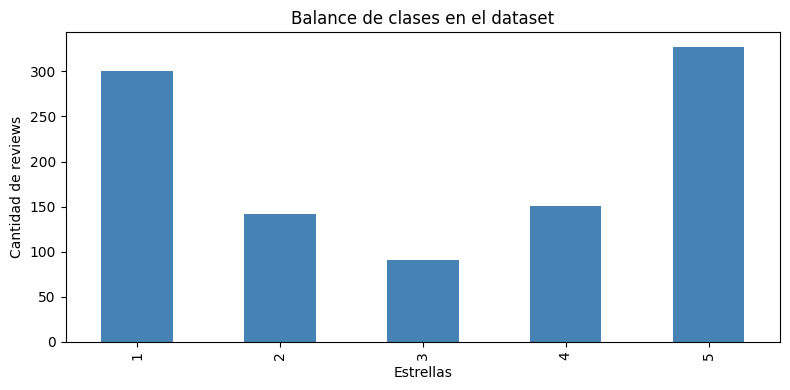


Ratio maxima/minima: 3.59
Hay desbalance. Un modelo entrenado aca aprendera sesgado hacia la clase mayoritaria.


In [23]:
import matplotlib.pyplot as plt

counts = df['stars'].value_counts().sort_index()
print("Cantidad por cada calificacion (1-5 estrellas):")
print(counts)

plt.figure(figsize=(8,4))
counts.plot(kind='bar', color='steelblue')
plt.title("Balance de clases en el dataset")
plt.xlabel("Estrellas")
plt.ylabel("Cantidad de reviews")
plt.tight_layout()
plt.show()

ratio = counts.max() / counts.min()
print(f"\nRatio maxima/minima: {ratio:.2f}")
if ratio > 2:
    print("Hay desbalance. Un modelo entrenado aca aprendera sesgado hacia la clase mayoritaria.")

## Paso 4 — Longitud de las reseñas por calificación

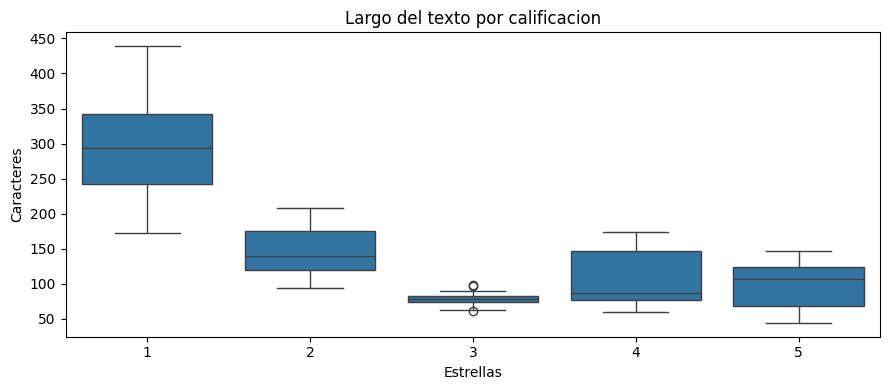

Observa: hay diferencias sistematicas de largo por categoria?
Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.


In [24]:
import seaborn as sns

df['largo'] = df['text'].str.len()

plt.figure(figsize=(9,4))
sns.boxplot(x='stars', y='largo', data=df)
plt.title("Largo del texto por calificacion")
plt.xlabel("Estrellas")
plt.ylabel("Caracteres")
plt.tight_layout()
plt.show()

print("Observa: hay diferencias sistematicas de largo por categoria?")
print("Si SI: un modelo podria aprender a usar el largo como pista, en vez del contenido.")

## Paso 5 — Valores faltantes

In [19]:
print("Valores faltantes por columna:\n")
print(df.isnull().sum())
print("\nFilas con texto vacío:", (df['text'].fillna('') == '').sum())
print("\nDuplicados por texto (ignorando el id):", df.duplicated(subset=['text']).sum())

Valores faltantes por columna:

id           0
text         8
stars        0
categoria    0
largo        8
dtype: int64

Filas con texto vacío: 8

Duplicados por texto (ignorando el id): 187


## TU TURNO — bitácora

Anota en la bitácora de tu proyecto:

1. ¿Cuál es la clase más representada? ¿Cuál la menos?
2. ¿Hay patrones de largo del texto que podrían ser un sesgo?
3. ¿Cómo se ve el equilibrio de tu propio dataset comparado con éste?

## Cierre
Guarda copia (`Archivo → Guardar copia en Drive`), descargala y súbela a tu repo en `notebooks/Clase_23.ipynb`.